# Test du khi2
## Importations

In [25]:
import pandas as pd
from scipy.stats import chi2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

## Fonction

In [26]:
def khi2(df,colonne1,colonne2,alpha):
    """
    df: le dataframe
    colonne1 et colonne2: nom des colonnes pour le test
    sep: séparateur du csv
    alpha: degré d'erreur
    """

    #tableau de contingence
    tab_contingence = pd.crosstab(df[colonne1],df[colonne2])
    print("Tableau de contingence:\n",tab_contingence)

    eff_observes = tab_contingence.values #extrait les données du df et les met en array

    #totaux marginaux
    total = eff_observes.sum()
    totaux_lignes = eff_observes.sum(axis=1,keepdims=True)
    totaux_colonnes = eff_observes.sum(axis=0,keepdims=True)

    #Calcul des effectifs théoriques
    theorique = (totaux_lignes*totaux_colonnes)/total
    print("Effectifs théoriques:\n",pd.DataFrame(theorique,index=tab_contingence.index,columns=tab_contingence.columns))

    condition = (theorique < 5).mean()
    if condition > 0.2:
        print(f"Condition non respectée : {condition*100:.1f}% des cellules < 5")
        return

    khi_2 = ((eff_observes-theorique)**2/theorique).sum()

    ddl= (eff_observes.shape[0]-1)*(eff_observes.shape[1]-1)

    p_value = 1 - chi2.cdf(khi_2,ddl)

    print(f"Khi² = {khi_2}")
    print(f"Degrés de liberté = {ddl}")
    print(f"p_value = {p_value}")

    #Interprétation à degré 5%
    if p_value < alpha:
        print(f'Résultat : dépendance significative entre {colonne1} et {colonne2} (p<{alpha})')
    else:
        print(f'Résultat : pas de dépendance significative entre {colonne1} et {colonne2} (p>={alpha})')

In [27]:
def heatmap(df, col1, col2, figsize=(10, 6)):
    """
    Affiche une heatmap pour visualiser la relation entre deux variables catégorielles.
    
    Paramètres :
        df      : DataFrame pandas
        col1    : variable en lignes
        col2    : variable en colonnes
        figsize : taille de la figure
    """
    # Tableau de contingence
    contingency = pd.crosstab(df[col1], df[col2])
    
    # Calcul via scipy
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Résidus standardisés
    residuals = (contingency - expected) / np.sqrt(expected)
    
    data = residuals
    title = f"Heatmap entre {col1} et {col2}"
    fmt = ".2f"
    cmap = "RdBu_r"
    center = 0

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        data,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        center=center,
        linewidths=0.5,
        ax=ax
    )
    
    # Statistiques dans le titre
    ax.set_title(f"{title}\nkhi²={chi2:.2f}, p={p:.4f}, ddl={dof}", fontsize=12)
    ax.set_xlabel(col2)
    ax.set_ylabel(col1)
    plt.tight_layout()
    plt.show()

## Création du dataframe

In [28]:
a_cat = pd.read_csv("gamesale_table_a_categorie.csv")
a_os = pd.read_csv("gamesale_table_a_os.csv")
a_tag = pd.read_csv("gamesale_table_a_tag.csv")
cat = pd.read_csv("gamesale_table_categorie.csv")
dev = pd.read_csv("gamesale_table_developpeur.csv")
editeur = pd.read_csv("gamesale_table_editeur.csv")
genre = pd.read_csv("gamesale_table_genre.csv")
jeux = pd.read_csv("gamesale_table_jeux.csv")
os = pd.read_csv("gamesale_table_os.csv")

df = pd.merge(jeux,dev)
df = pd.merge(df,editeur)
df = pd.merge(df,genre)
print(df.head())

   id_jeu                       nom_jeu   annee  age_requis  nb_succes  \
0       1            grand theft auto v  2015.0          18         77   
1       2  grand theft auto san andreas  2008.0          18          0   
2       3    grand theft auto vice city  2011.0          18          0   
3       4        call of duty black ops  2010.0          18         68   
4       5     call of duty black ops ii  2012.0          18         35   

   nb_avis_pos  nb_avis_neg  temps_jeu_moyen   prix  \
0       329061       139308             9837  24.99   
1        26877         3243              807   9.99   
2         9817          819              209   5.99   
3        14201         1839             2672  29.99   
4        25827         4658              524  39.99   

                                         description  ... ventes_EU ventes_JP  \
0  Los Santos is a city of bright lights, long ni...  ...     23,04      1,39   
1  Five years ago Carl Johnson escaped from the p...  ...     

## Genre et éditeur
La condition de la fréquence attendue au dessus de 5 pour chaque cellule n'est pas respectée. Nous avons beau regrouper des éditeurs et des genres avant de faire le test, le test est infaisable.

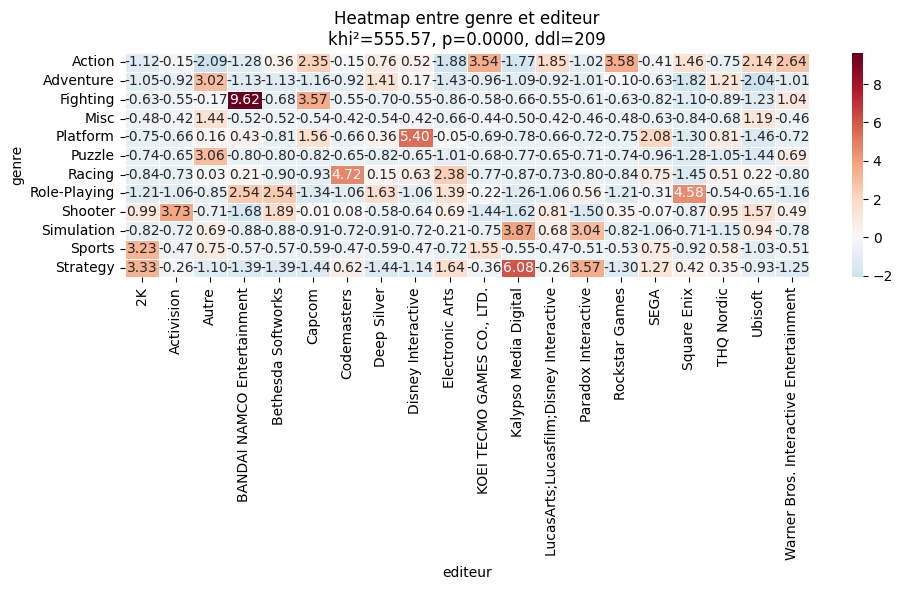

Tableau de contingence:
 editeur       2K  Activision  Autre  BANDAI NAMCO Entertainment  \
genre                                                             
Action         1           2     78                           1   
Adventure      0           0     56                           0   
Fighting       0           0     13                           7   
Misc           0           0     12                           0   
Platform       0           0     20                           1   
Puzzle         0           0     32                           0   
Racing         0           0     24                           1   
Role-Playing   0           0     44                           5   
Shooter        4           7     77                           0   
Simulation     0           0     26                           0   
Sports         2           0     12                           0   
Strategy       6           1     49                           0   

editeur       Bethesda Softworks  Ca

In [29]:
seuil = 10
top_editeurs = df["editeur"].value_counts()
top_editeurs = top_editeurs[top_editeurs >= seuil].index

df_filtre = df.copy()
df_filtre["editeur"] = df_filtre["editeur"].where(
    df_filtre["editeur"].isin(top_editeurs), other="Autre"
)

seuil_genre = 10
top_genres = df_filtre["genre"].value_counts()
top_genres = top_genres[top_genres >= seuil_genre].index

df_filtre["genre"] = df_filtre["genre"].where(
    df_filtre["genre"].isin(top_genres), other="Autre"
)

heatmap(df_filtre,"genre","editeur")
khi2(df_filtre,"genre","editeur",0.05)

## Genre et développeur

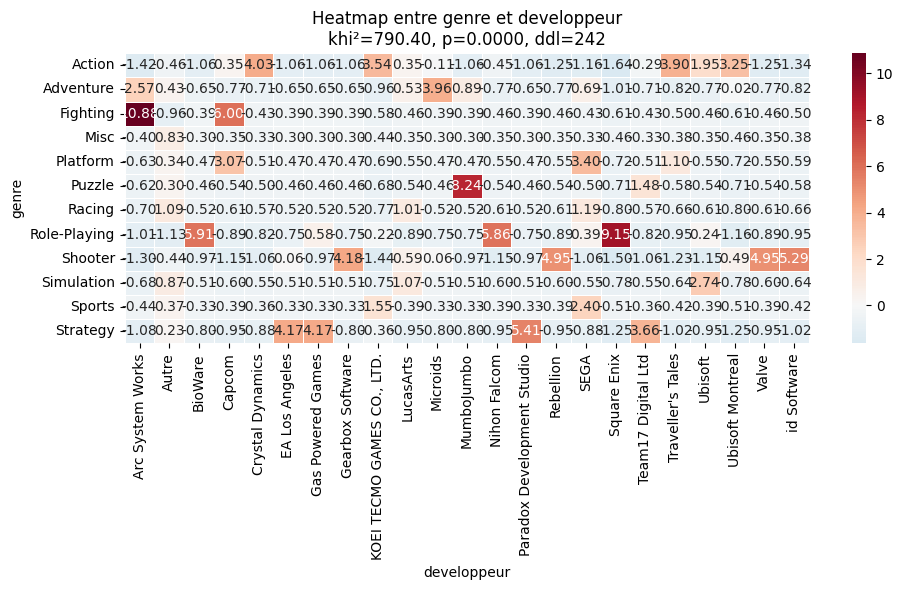

Tableau de contingence:
 developpeur   Arc System Works  Autre  BioWare  Capcom  Crystal Dynamics  \
genre                                                                      
Action                       0    134        0       2                 6   
Adventure                    3     56        0       0                 0   
Fighting                     6     15        0       3                 0   
Misc                         0     14        0       0                 0   
Platform                     0     29        0       2                 0   
Puzzle                       0     28        0       0                 0   
Racing                       0     40        0       0                 0   
Role-Playing                 0     61        5       0                 0   
Shooter                      0    113        0       0                 0   
Simulation                   0     37        0       0                 0   
Sports                       0     15        0       0         

In [33]:
seuil = 5
top_developpeur = df["developpeur"].value_counts()
top_developpeur = top_developpeur[top_developpeur >= seuil].index

df_filtre = df.copy()
df_filtre["developpeur"] = df_filtre["developpeur"].where(
    df_filtre["developpeur"].isin(top_developpeur), other="Autre"
)

seuil_genre = 5
top_genres = df_filtre["genre"].value_counts()
top_genres = top_genres[top_genres >= seuil_genre].index

df_filtre["genre"] = df_filtre["genre"].where(
    df_filtre["genre"].isin(top_genres), other="Autre"
)

heatmap(df_filtre,"genre","developpeur")
khi2(df_filtre,"genre","developpeur",0.05)

## Genre et catégorie
Les genres et catégories avec moins de 40 occurrences ont été exclus de l'analyse afin de respecter les conditions d'application du test du khi²

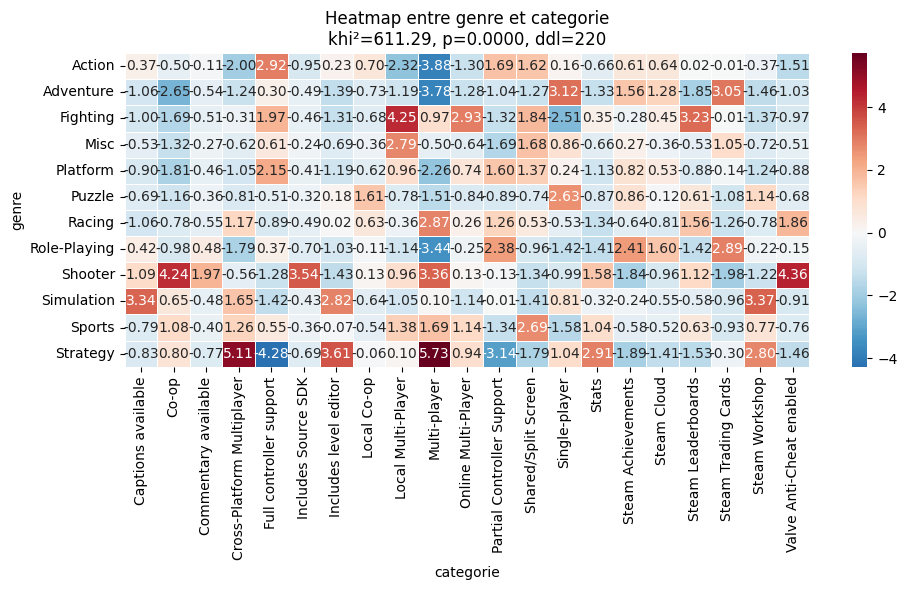

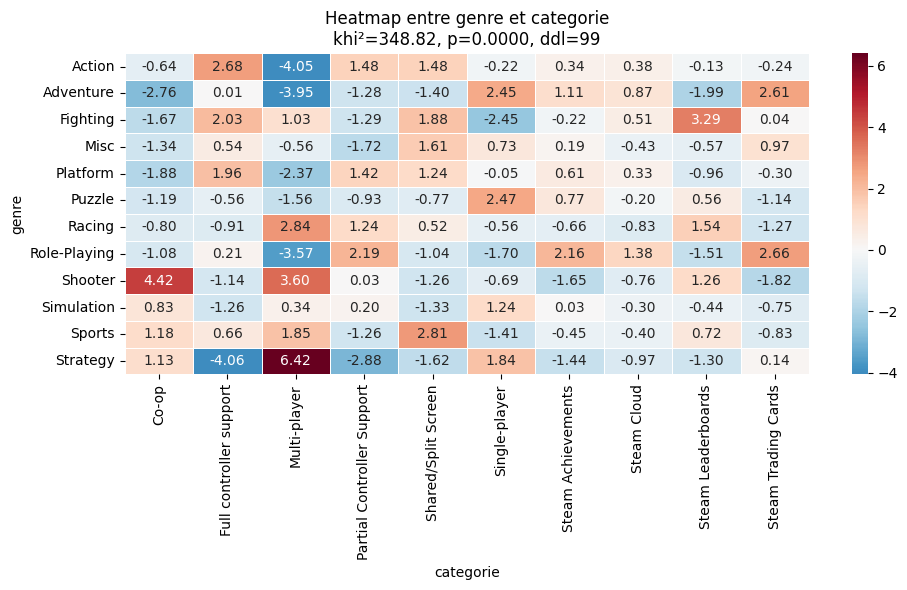

Tableau de contingence:
 categorie     Co-op  Full controller support  Multi-player  \
genre                                                        
Action           24                       65            31   
Adventure         0                       13             1   
Fighting          2                       17            18   
Misc              0                        4             3   
Platform          1                       15             4   
Puzzle            1                        4             3   
Racing            5                        9            28   
Role-Playing     11                       27            14   
Shooter          45                       33            81   
Simulation        7                        5            13   
Sports            6                        8            14   
Strategy         17                        3            65   

categorie     Partial Controller Support  Shared/Split Screen  Single-player  \
genre                     

In [45]:
df_cat = pd.merge(jeux, a_cat, on="id_jeu")
df_cat = pd.merge(df_cat, cat, on="id_cat")
df_cat = pd.merge(df_cat, genre, on="id_jeu")

heatmap(df_cat,"genre","categorie")
# Tri des genre sous représentés
seuil = 40

genres_freq = df_cat["genre"].value_counts()
cat_freq = df_cat["categorie"].value_counts()

df_filtre = df_cat[
    df_cat["genre"].isin(genres_freq[genres_freq >= seuil].index) &
    df_cat["categorie"].isin(cat_freq[cat_freq >= seuil].index)
]

heatmap(df_filtre,"genre","categorie")
khi2(df_filtre, "genre", "categorie", 0.05)

## Genre et tag

## Genre et OS

## Genre et âge requis

## Genre et année

## Genre et anglais

## Editeur et développeur